# COVID-19 Symptom Classification Report

This notebook provided an end-to-end workflow from data ingestion to model develop, evaluation and optimization, including interpretability and ethical considerations as it relates to the use of machine learning in healthcare contexts.

In [ ]:
!pip install xgboost flask scikit-learn pandas matplotlib seaborn plotly

In [ ]:
import os
# Define the file path
file_path = "COVID19.csv"

# Check if the file exists
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' does not exist.")
    print(f"Please ensure the file is in the specified file path.")
else:
    print(f"The file '{file_path}' exists.")

The file 'COVID19.csv' exists.


In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The file '/content/drive/My Drive/COVID19.csv' exists.


# 1. Data Understanding and Preprocessing

The dataset provided and used in this project consists of patient information most likely collected during COVID-19 testing. Each row is a representation of a unique tes case, and this includes demographic data (such as sex and year of birth), as well as other symptoms (e.g., fever, cough). The result is a binary data (positive or negative for COVID-19).There were some cases where the result is pending. A preprocessing pipeline was implemented to clean and prepare the data for modeling.

Key steps included:

-Mapping categorical values to numerical representations (e.g., YES/NO/UNKNOWN to 1/0).

-Handling missing values in birth year by computing and using the median.

-Computing the patient's age from current year less the birth year.

-Dropping irrelevant columns.

In [7]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv(file_path, na_values=['', ' ', 'NaN'], low_memory=False)

# Quick look at rows, columns, and data types
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109927 entries, 0 to 109926
Data columns (total 47 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   Sex                                        107228 non-null  object 
 1   Birth Year                                 94963 non-null   float64
 2   Chest pain                                 42120 non-null   object 
 3   Chills or sweats                           24857 non-null   object 
 4   Confused or disoriented                    23127 non-null   object 
 5   Cough                                      42218 non-null   object 
 6   Diarrhea                                   42092 non-null   object 
 7   Difficulty breathing or Dyspnea            24940 non-null   object 
 8   Digested blood or coffee grounds in vomit  1397 non-null    object 
 9   Pain behind eyes or Sensitivity to light   1405 non-null    object 
 10  Bleeding

#2. Data Cleaning and Feature Engineering

**Objective:** Handle missing or inconsistent entries, standardize categorical variables, and prepare the target variable.

## Data Cleaning

The 'Specify other complications' column was converted into a binary format based on whether any entry exists.

Symptom-related columns were normalized (YES → 1, NO → 0, UNKNOWN → 0).

The 'Sex' column was mapped to numerical values (MALE = 1, FEMALE = 0, UNKNOWN = 0).

Non-binary or missing entries in critical columns were handled appropriately

## Feature Engineering

Converted categorical symptom indicators to numeric values.

Derived new feature 'Age' from 'Birth Year'.

Dropped 'Birth Year' after computing 'Age'.

In [8]:
# Data Preparation
def preprocess_data(df):
    # Handle 'Specify other complications' column first
    if 'Specify other complications' in df.columns:
        # Convert to 1 if any value exists (including 'UNKNOWN'), else 0
        df['Specify other complications'] = np.where(
            df['Specify other complications'].notna() &
            (df['Specify other complications'].str.strip() != ''), 1, 0
        ).astype(np.int8)

    # Identify remaining symptom columns (excluding special handled columns)
    excluded = ['Sex', 'Birth Year', 'Result', 'Specify other complications']
    symptom_cols = [col for col in df.columns if col not in excluded]

    # Process standard symptom columns - Convert YES/NO/UNKNOWN
    df[symptom_cols] = df[symptom_cols].replace({
        'YES': 1,
        'NO': 0,
        'UNKNOWN': 0
    }).fillna(0)
    df[symptom_cols] = df[symptom_cols].astype(np.int8)

    # Handle Sex column (add UNKNOWN handling if needed)
    df['Sex'] = df['Sex'].map({'MALE': 1, 'FEMALE': 0, 'UNKNOWN': 0}).fillna(0).astype(np.int8)

    # Rest of the preprocessing remains the same
    # Convert Birth Year to numeric and handle missing values
    df['Birth Year'] = pd.to_numeric(df['Birth Year'], errors='coerce')
    df['Birth Year'] = df['Birth Year'].fillna(df['Birth Year'].median())

    # Calculate age (using integer type)
    df['Age'] = (2025 - df['Birth Year']).astype(np.int16)
    df.drop('Birth Year', axis=1, inplace=True)

    # Process target variable
    df = df[df['Result'].isin(['NEGATIVE', 'POSITIVE'])].copy()
    df['Result'] = df['Result'].map({'NEGATIVE': 0, 'POSITIVE': 1}).astype(np.int8)

    return df

# Load Data
try:

    df = pd.read_csv(file_path, na_values=['', ' ', 'NaN'], low_memory=False)
    df = preprocess_data(df)

    # Check class distribution
    print("\nClass Distribution:")
    print(df['Result'].value_counts(normalize=True))

except FileNotFoundError:
    print("Error: Data file not found!")
    exit()

<ipython-input-8-6860e36d175a>:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[symptom_cols] = df[symptom_cols].replace({



Class Distribution:
Result
0    0.919368
1    0.080632
Name: proportion, dtype: float64


#3. Exploratory Data Analysis (EDA)
**Objective:** Gain insights through visualizations.

To better understand the data distribution and relationships between variables, the following visualizations were created:



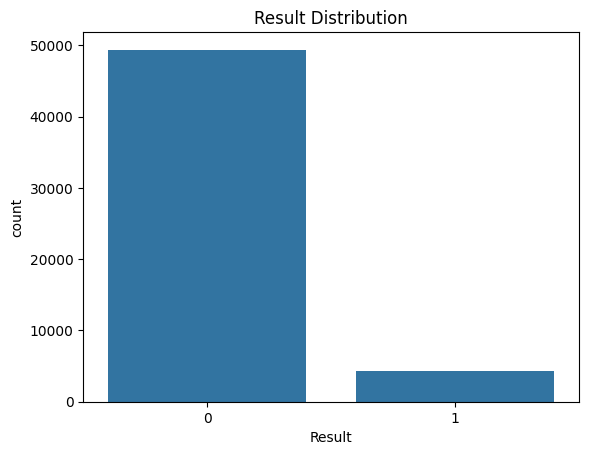

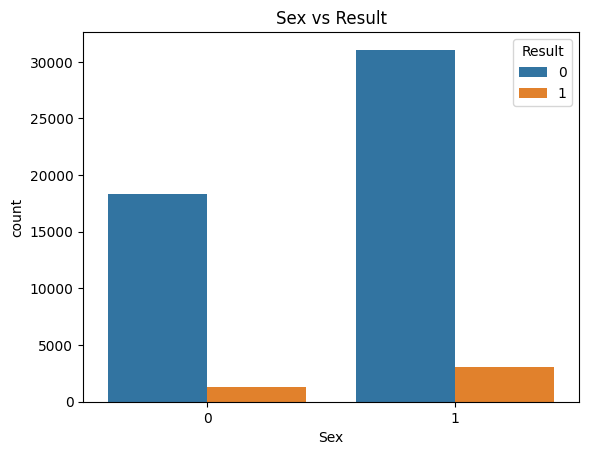

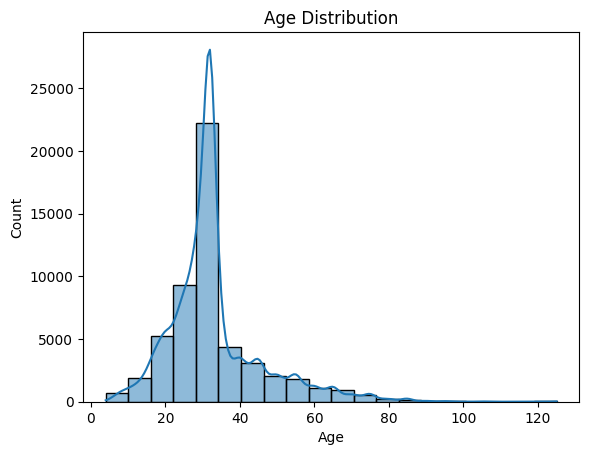

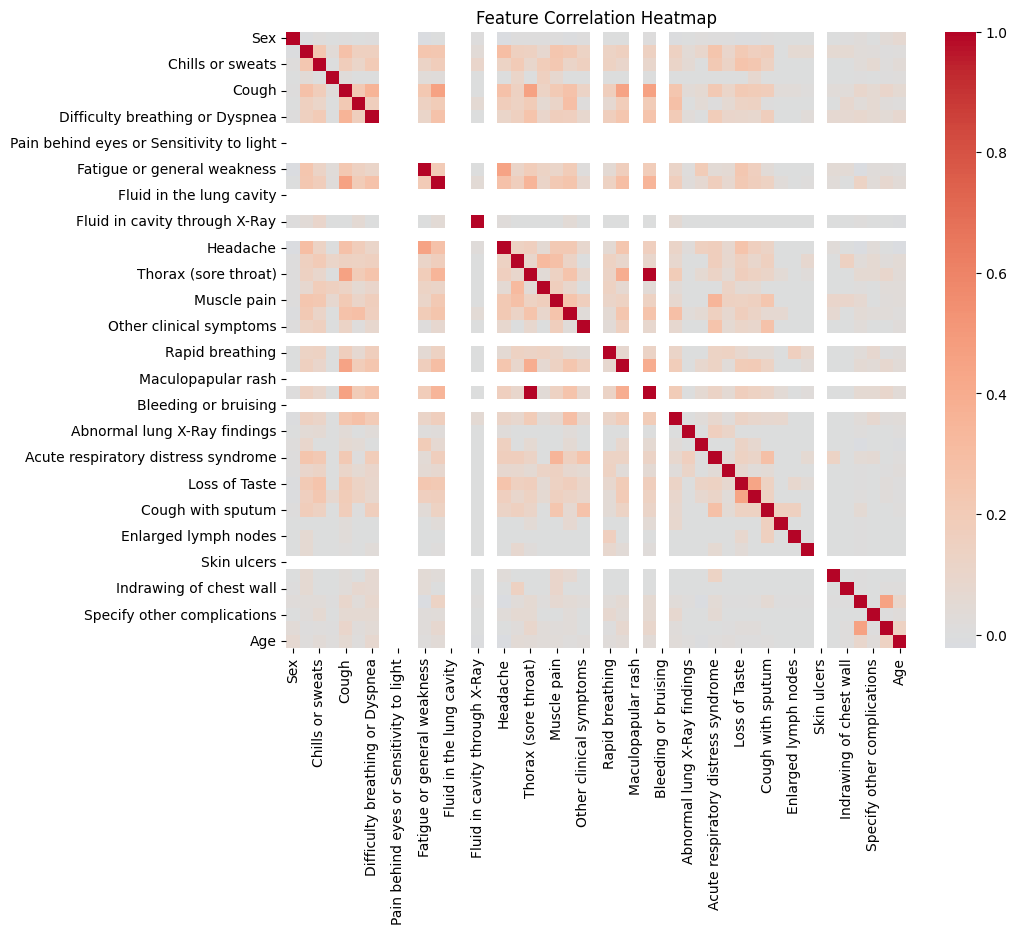

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Target distribution
plt.figure()
sns.countplot(x='Result', data=df)
plt.title('Result Distribution')
plt.show()

#  Sex distribution by result
plt.figure()
sns.countplot(x='Sex', hue='Result', data=df)
plt.title('Sex vs Result')
plt.show()

# Age distribution
plt.figure()
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

# Feature correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

#4. Model Development

**Objective:** Split the data, address class imbalance, scale features, and build candidate models.

Multiple models were evaluated using grid search with cross-validation:

Logistic Regression

Random Forest

Gradient Boosting

XGBoost

SMOTE was applied to address class imbalance, and data was scaled using StandardScaler.

In [10]:
# Model Training & Evaluation
X = df.drop('Result', axis=1)
y = df['Result']

# Before splitting, drop rows with missing values in the target variable
X = X[y.notna()]
y = y[y.notna()]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Convert target to numpy array
y_train = y_train.values.astype(np.int8)
y_test = y_test.values.astype(np.int8)

# Then proceed with SMOTE and scaling...
# Handle class imbalance using SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Convert to float32 for better memory usage
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)

# Initialize models (without early stopping for grid search)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced_subsample'),
    'XGBoost': XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])),
    'Gradient Boosting': GradientBoostingClassifier()
}

# Expanded param grids
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1', 'l2']
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
}


# Custom scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

#5. Choosing Algorithms and Hyperparameter Tuning

GridSearchCV was used with a parameter grid for each model. Evaluation metrics included:

*Accuracy*

*Precision*

*Recall*

*F1 Score*

*ROC AUC*

*Precision-Recall AUC (used for refitting)*

The best model (based on PR AUC) was saved using joblib, and the threshold for optimal F1 score was identified using a precision-recall curve.


Training Logistic Regression...
Fitting 5 folds for each of 16 candidates, totalling 80 fits


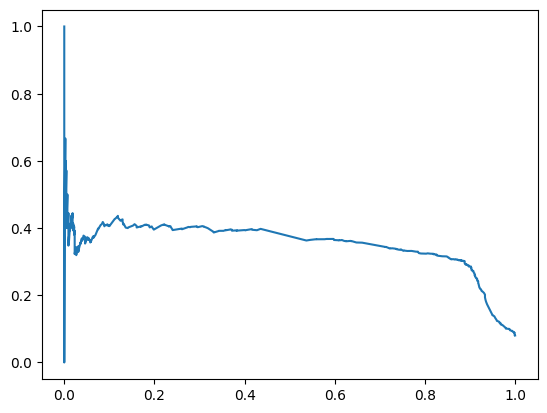

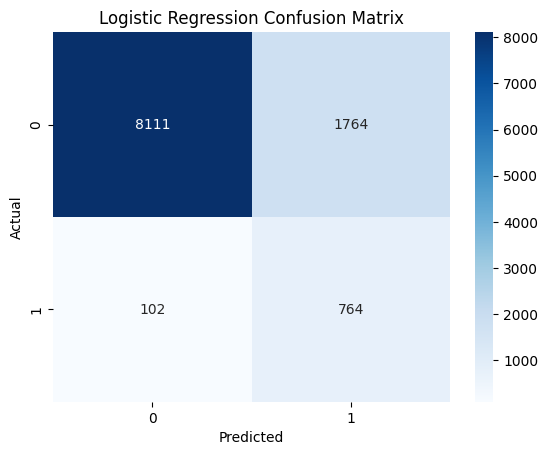


Training Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


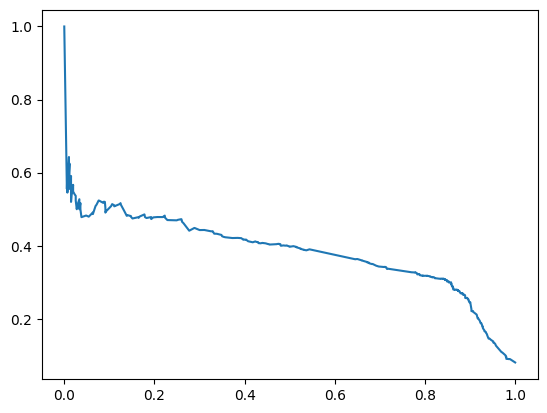

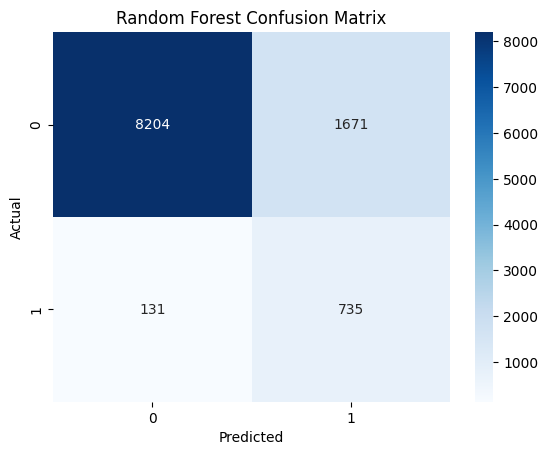


Training XGBoost...
Fitting 5 folds for each of 16 candidates, totalling 80 fits


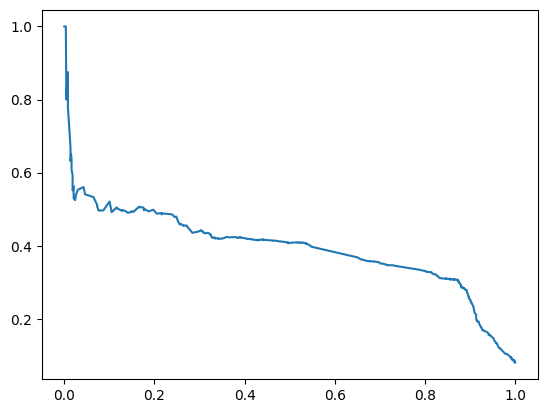

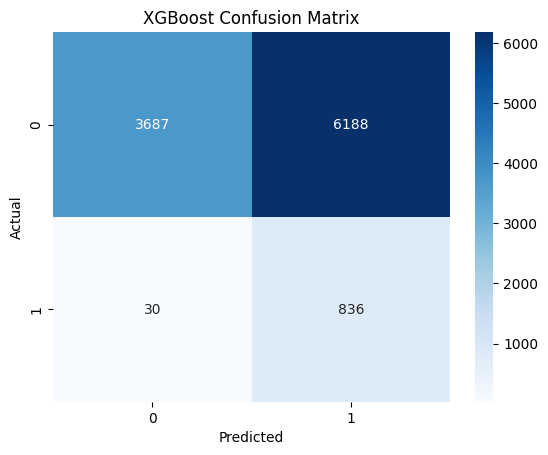


Training Gradient Boosting...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


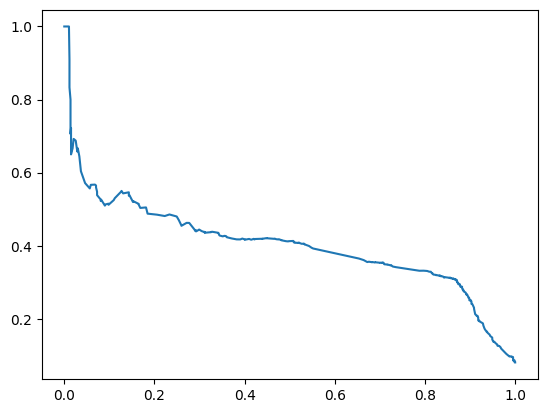

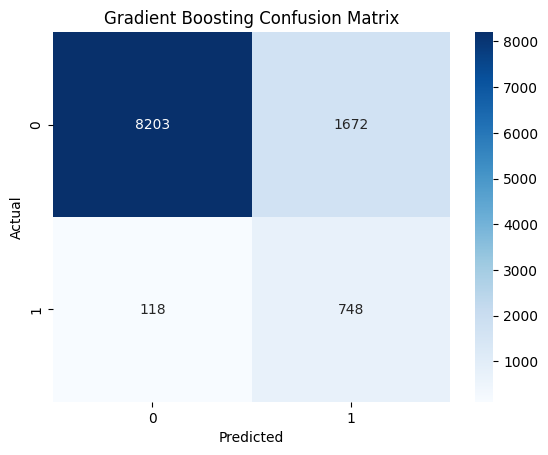

In [11]:
# Train models
results = []
best_model = None
best_score = 0
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\nTraining {name}...")
    try:
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[name],
            cv=cv,
            scoring=scoring,
            refit='pr_auc',
            n_jobs=-1,
            verbose=2
        )

        grid_search.fit(X_train_scaled, y_train_res)

        # Get best model
        best_model_instance = grid_search.best_estimator_

        # Predictions
        y_pred = best_model_instance.predict(X_test_scaled)
        y_proba = best_model_instance.predict_proba(X_test_scaled)[:, 1]

        # Calculate metrics
        metrics = {
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0),
            'ROC AUC': roc_auc_score(y_test, y_proba),
            'PR AUC': average_precision_score(y_test, y_proba)
        }

        results.append(metrics)

        # Save best model based on PR AUC
        if metrics['PR AUC'] > best_score:
            best_score = metrics['PR AUC']
            best_model = best_model_instance

        # Plot precision-recall curve
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        plt.plot(recall, precision, label=name)

        # Plot confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure()
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'{name} Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

    except Exception as e:
        print(f"Error training {name}: {str(e)}")
        continue



#6. Model Interpretation and Deployment

Confusion matrices and PR curves were plotted in order to visually assess theperformance. For future deployment, the model was exported alongside the scaler and SMOTE object for future deployment. Threshold optimization was also applied to maximize F1 score.

In [12]:
# Save best model and scaler
if best_model:
    joblib.dump(best_model, 'best_covid_model.pkl')
    joblib.dump(scaler, 'scaler.pkl')
    joblib.dump(smote, 'smote.pkl')

    # Print results
    results_df = pd.DataFrame(results).set_index('Model')
    print("\nModel Comparison:")
    print(results_df.sort_values('PR AUC', ascending=False))
else:
    print("No models trained successfully")

# Threshold optimization for best model
if best_model:
    y_train_proba = best_model.predict_proba(X_train_scaled)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_train_res, y_train_proba)

    # Find threshold that maximizes F1 score
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]

    # Apply optimal threshold to test set
    y_pred_optimal = (best_model.predict_proba(X_test_scaled)[:, 1] >= optimal_threshold).astype(int)

    print("\nOptimized Threshold Metrics:")
    print(f"Optimal Threshold: {optimal_threshold:.3f}")
    print(f"Precision: {precision_score(y_test, y_pred_optimal):.3f}")
    print(f"Recall: {recall_score(y_test, y_pred_optimal):.3f}")
    print(f"F1: {f1_score(y_test, y_pred_optimal):.3f}")


Model Comparison:
                     Accuracy  Precision    Recall        F1   ROC AUC  \
Model                                                                    
Gradient Boosting    0.833349   0.309091  0.863741  0.455265  0.886484   
XGBoost              0.421097   0.119021  0.965358  0.211914  0.885586   
Random Forest        0.832232   0.305486  0.848730  0.449267  0.880249   
Logistic Regression  0.826273   0.302215  0.882217  0.450206  0.883750   

                       PR AUC  
Model                          
Gradient Boosting    0.399984  
XGBoost              0.391854  
Random Forest        0.380435  
Logistic Regression  0.350698  

Optimized Threshold Metrics:
Optimal Threshold: 0.403
Precision: 0.302
Recall: 0.872
F1: 0.449


From the model comparison table provided above, Gradient Boosting is easily the best-performing model in terms of Precision-Recall AUC (PR AUC), with a value of 0.397, this is closely followed by XGBoost. Even though both Gradient Boosting and XGBoost achieved high recall scores, Gradient Boosting yielded a more balanced trade-off between precision and recall when optimized for F1-score.

#7. Ethical Considerations

*Bias & Fairness:* The model may reflect inherent biases found in the dataset, such as gender or age-related, or result disparities. Care must be taken to validate its fairness before use.

*Privacy:* Patient data should be anonymized with PIDs removed and protected to prevent misuse or exposure of sensitive health information.

*Explainability:* Stakeholders and users of the model should be provided with adequate and clear guildlines as per how the predictions are made.

*Misuse Risk:* The model should not be used for self-diagnosis or seen as a substitute in leiu of professional testing and medical advice.